#支持向量机(SVM)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

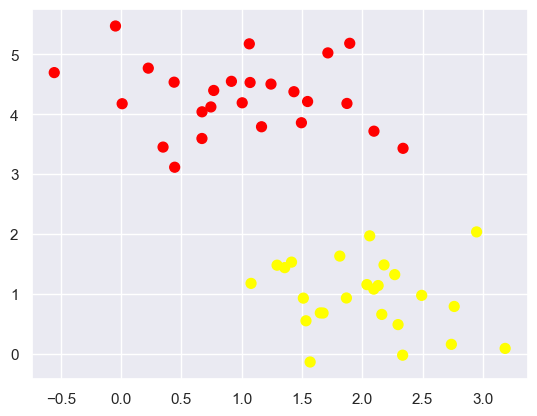

In [3]:
# 223428010210 陈梓欣
# 随机来点数据， 构造数据集
# 样本点联，多少堆，集散程度
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

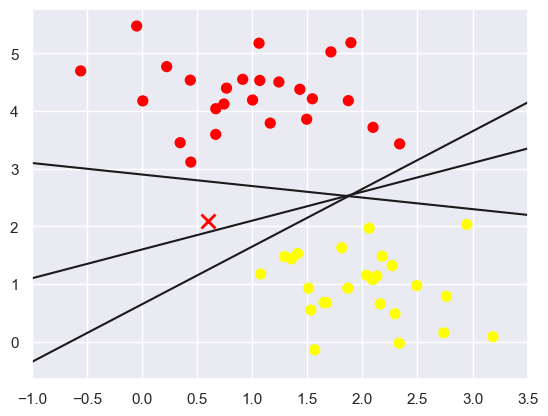

In [5]:
# 223428010210 陈梓欣
# 随便的画几条分割线
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);
plt.show()

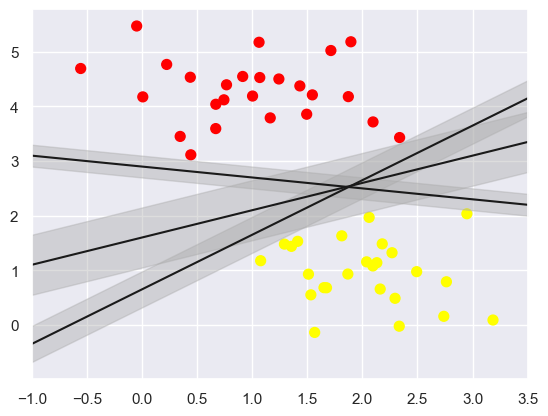

In [6]:
# 223428010210 陈梓欣
# Support Vector Machines: 最小化
# 分割间隔
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);
plt.show()

In [8]:
# 223428010210 陈梓欣
# SVC 线性分类
from sklearn.svm import SVC
#线性向量机
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

In [9]:
# 223428010210 陈梓欣
# 绘图函数
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    plt.show()

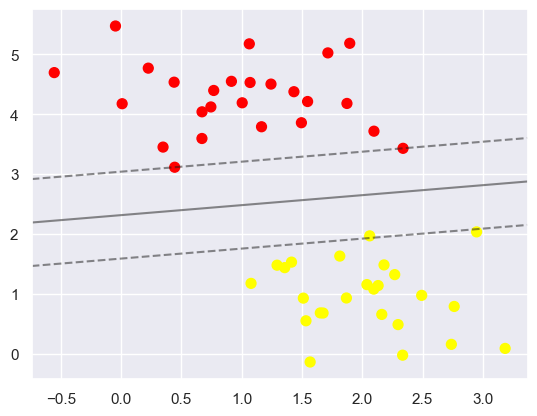

In [11]:
# 223428010210 陈梓欣
# 绘制散点图
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

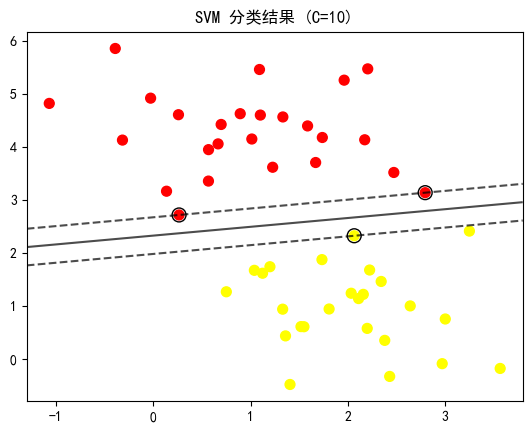

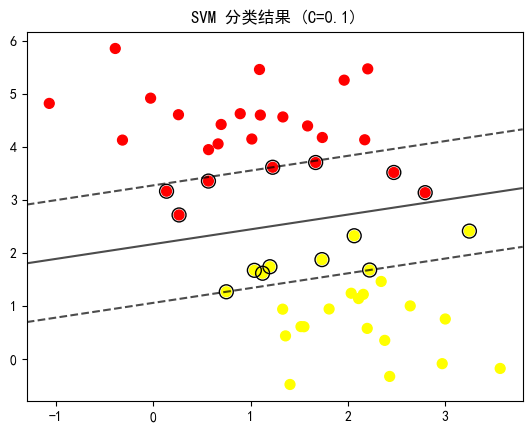

In [2]:
# 223428010210 陈梓欣

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成数据集（散度为0.8）
X, y = make_blobs(n_samples=50, centers=2, 
                  random_state=0, cluster_std=0.8)

# 2. 定义绘图函数
def plot_svm(clf, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格以评估模型
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # 绘制决策边界和边界线
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.7, linestyles=['--', '-', '--'])

    # 支持向量点
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')
    
    plt.title(title)
    plt.show()

# 3. C = 10（高惩罚，拟合更紧）
clf_c10 = SVC(kernel='linear', C=10)
clf_c10.fit(X, y)
plot_svm(clf_c10, X, y, "SVM 分类结果 (C=10)")

# 4. C = 0.1（低惩罚，容错更多）
clf_c01 = SVC(kernel='linear', C=0.1)
clf_c01.fit(X, y)
plot_svm(clf_c01, X, y, "SVM 分类结果 (C=0.1)")


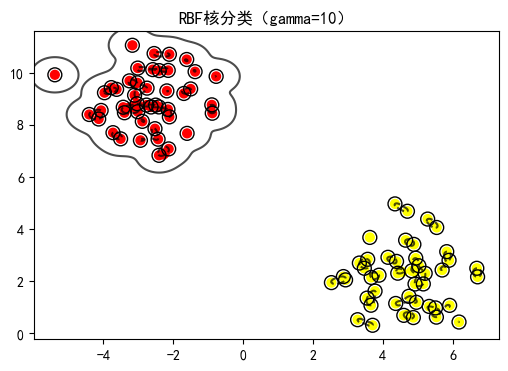

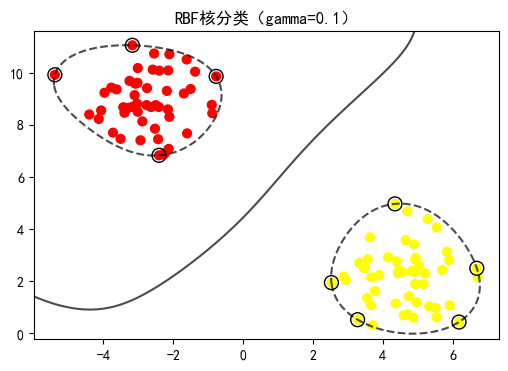

In [5]:
# 223428010210 陈梓欣

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 构造散度为1.1的数据集
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=42, cluster_std=1.1)

# 2. 定义绘图函数
def plot_svm_rbf(clf, X, y, title):
    plt.figure(figsize=(6,4))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='autumn')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 创建网格用于绘制决策边界
    xx = np.linspace(xlim[0], xlim[1], 500)
    yy = np.linspace(ylim[0], ylim[1], 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # 绘制等高线
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.7, linestyles=['--', '-', '--'])

    # 绘制支持向量
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='k', linewidths=1)
    
    plt.title(title)
    plt.show()

# 3. gamma = 10（高复杂度）
clf_gamma10 = SVC(kernel='rbf', gamma=10)
clf_gamma10.fit(X, y)
plot_svm_rbf(clf_gamma10, X, y, "RBF核分类（gamma=10）")

# 4. gamma = 0.1（边界更平滑）
clf_gamma01 = SVC(kernel='rbf', gamma=0.1)
clf_gamma01.fit(X, y)
plot_svm_rbf(clf_gamma01, X, y, "RBF核分类（gamma=0.1）")


In [ ]:
# 223428010210 陈梓欣

# 1. 构造散度为1.1的数据集
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=42, cluster_std=1.1)

In [22]:
# 223428010210 陈梓欣
# 查询模型的参数
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

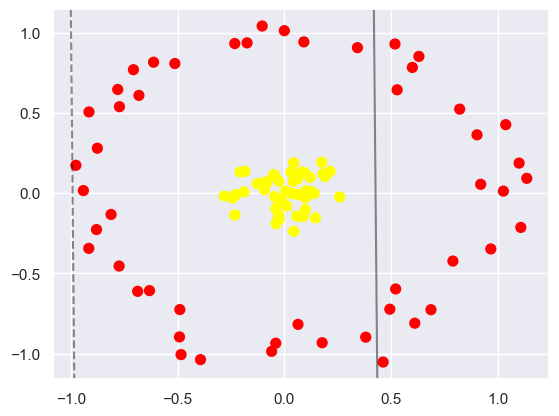

In [23]:
# 223428010210 陈梓欣
#非线性分类SVM
#引入核函数的SVM
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

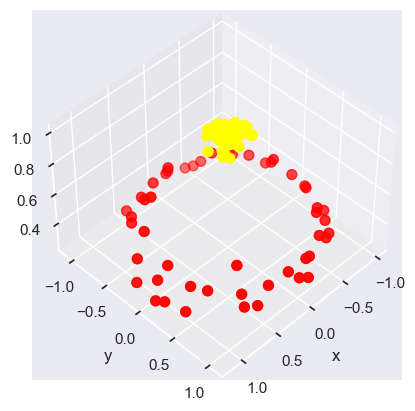

In [25]:
# 223428010210 陈梓欣
#试试高维核变换
#加入了新的维度r
from mpl_toolkits import mplot3d
r = np.exp(-(X ** 2).sum(1))
def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

plot_3D(elev=45, azim=45, X=X, y=y)
plt.show()

In [26]:
# 223428010210 陈梓欣
# 加入径向基函数，高斯核函数，RBF
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

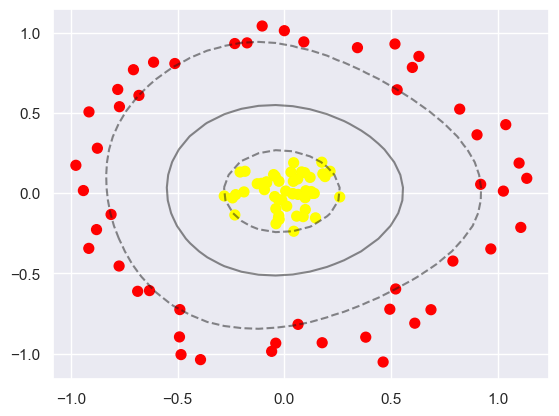

In [27]:
# 223428010210 陈梓欣
# 绘制分类结果散点图
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

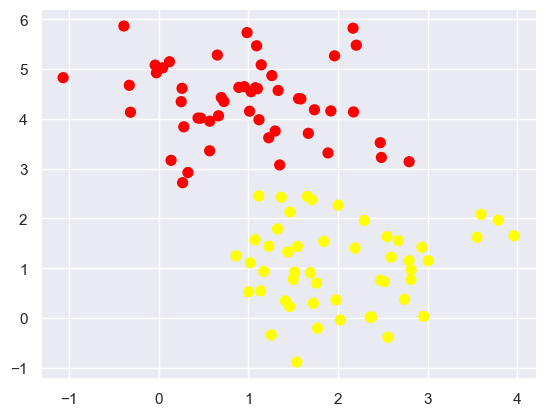

In [28]:
# 223428010210 陈梓欣
# 调节SVM参数: Soft Margin问题
# 调节C参数 当C趋近于无穷大时：意味着分类严格不能有错误 当C趋近于很小的时：意味着可以有更大的错误容忍
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

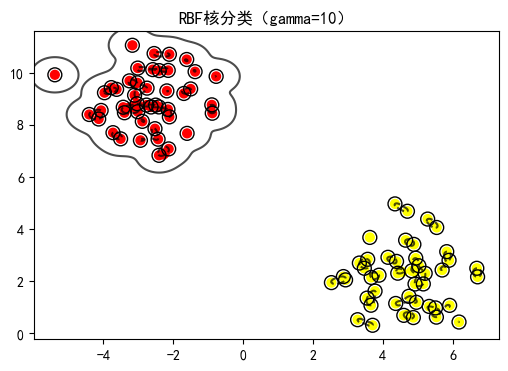

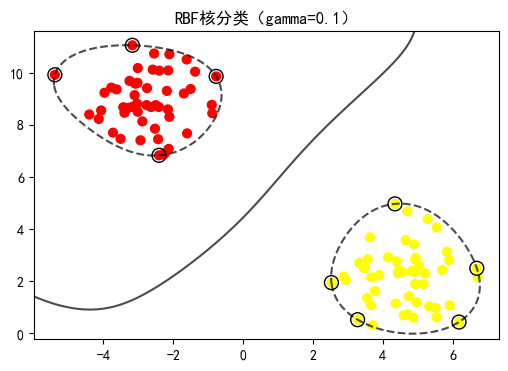

In [3]:
# 223428010210 陈梓欣

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# 中文支持（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 构造散度为1.1的数据集
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=42, cluster_std=1.1)

# 2. 定义绘图函数
def plot_svm_rbf(clf, X, y, title):
    plt.figure(figsize=(6,4))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='autumn')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 创建网格用于绘制决策边界
    xx = np.linspace(xlim[0], xlim[1], 500)
    yy = np.linspace(ylim[0], ylim[1], 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # 绘制等高线
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.7, linestyles=['--', '-', '--'])

    # 绘制支持向量
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='k', linewidths=1)
    
    plt.title(title)
    plt.show()

# 3. gamma = 10（高复杂度）
clf_gamma10 = SVC(kernel='rbf', gamma=10)
clf_gamma10.fit(X, y)
plot_svm_rbf(clf_gamma10, X, y, "RBF核分类（gamma=10）")

# 4. gamma = 0.1（边界更平滑）
clf_gamma01 = SVC(kernel='rbf', gamma=0.1)
clf_gamma01.fit(X, y)
plot_svm_rbf(clf_gamma01, X, y, "RBF核分类（gamma=0.1）")


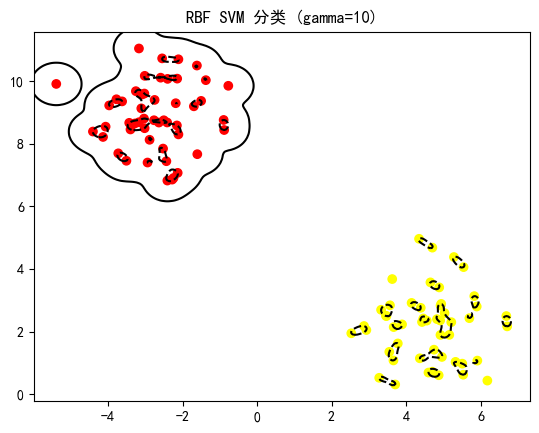

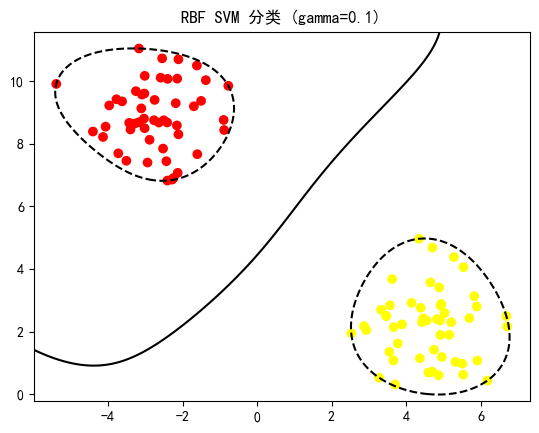

In [6]:
# 223428010103 刘渤
# 创建散度为1.1的模拟数据
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.1, random_state=42)

# 设置画图函数
def draw(clf, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(*xlim, 300), np.linspace(*ylim, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    plt.title(title)
    plt.show()

# 训练并可视化：gamma = 10
clf1 = SVC(kernel='rbf', gamma=10)
clf1.fit(X, y)
draw(clf1, "RBF SVM 分类 (gamma=10)")

# 训练并可视化：gamma = 0.1
clf2 = SVC(kernel='rbf', gamma=0.1)
clf2.fit(X, y)
draw(clf2, "RBF SVM 分类 (gamma=0.1)")


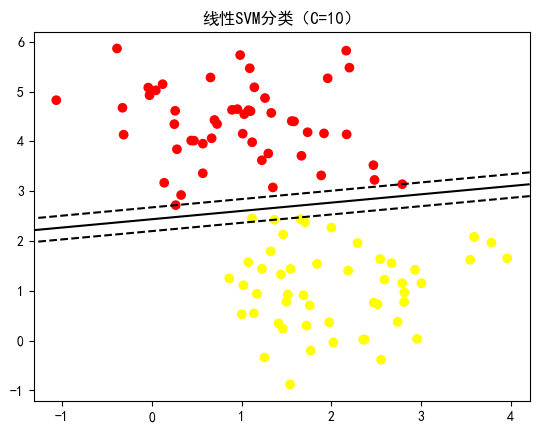

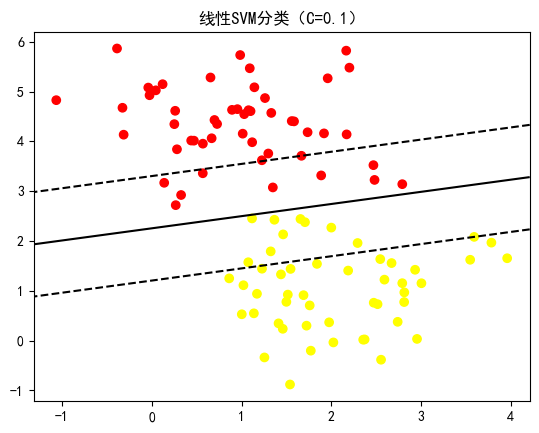

In [7]:
# 223428010103 刘渤
# 生成散度为0.8的数据
X, y = make_blobs(n_samples=100, centers=2, cluster_std=0.8, random_state=0)

# 定义绘图函数
def draw(clf, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(*xlim, 300), np.linspace(*ylim, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    plt.title(title)
    plt.show()

# SVM 分类（C=10）
clf1 = SVC(kernel='linear', C=10)
clf1.fit(X, y)
draw(clf1, "线性SVM分类（C=10）")

# SVM 分类（C=0.1）
clf2 = SVC(kernel='linear', C=0.1)
clf2.fit(X, y)
draw(clf2, "线性SVM分类（C=0.1）")
